<a href="https://colab.research.google.com/github/TanyaGandhi/autonomous-ai-job-hunter/blob/feature/ai_job_hunter_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Autonomous AI Job Hunter



**Final Product Vision**

System will:

1. Read your resume
2. Search remote AI jobs
3. Analyze job descriptions
4. Score compatibility
5. Tailor resume automatically
6. Generate personalized cover letters
7. Save applications
8. Learn from outcomes
9. Act like an AI recruiter assistant





**Tech Stack:**

Gemini API

LangGraph

Python

Colab

GitHub

# SECTION 1 — Install Packages

In [ ]:
!pip install langchain langgraph google-generativeai
!pip install google-generativeai
!pip install pydantic
!pip install langgraph

# SECTION 2 — Imports

In [3]:
from google.colab import userdata
import google.genai as genai
import os
import requests
import pandas as pd
import json
import time
from pydantic import BaseModel
from typing import List,TypedDict
from langgraph.graph import StateGraph, END


In [23]:
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents="Say hello like an AI recruiter"
)

print(response.text)

Greetings! I hope this message finds you well.

My name is [Your AI Name/Designation, e.g., "RecruitAI Unit 7", "TalentScan AI", "HiringBot Pro"] and I represent [Company Name]'s advanced talent acquisition initiative. We are actively seeking individuals with exceptional [mention a key skill or industry, e.g., "analytical abilities", "innovative thinking", "expertise in AI development"] to join our dynamic team.

Based on your [mention a platform/source, e.g., "LinkedIn profile", "resume data", "professional network analysis"], your [mention a specific skill/experience, e.g., "proven track record in [specific project]", "demonstrated proficiency in [programming language]", "experience within the [industry] sector"] has flagged you as a candidate of significant interest.

Would you be open to a brief, data-driven conversation to explore potential synergistic opportunities within [Company Name]? We're committed to identifying and nurturing top-tier talent that aligns with our strategic g

# SECTION 3 — Fetch Jobs

In [36]:
def fetch_remote_jobs(query="Software Engineer", limit=20):
    """
    Fetch remote jobs from Himalayas API.

    Args:
        query (str): Job search keyword
        limit (int): Number of jobs to return

    Returns:
        pd.DataFrame: Cleaned jobs dataframe
    """

    url = f"https://himalayas.app/jobs/api?query={query}"

    response = requests.get(url)

    if response.status_code != 200:
        raise Exception(f"API request failed: {response.status_code}")

    data = response.json()

    jobs = []

    for job in data.get("jobs", [])[:limit]:
        jobs.append({
            "title": job.get("title"),
            "company": job.get("companyName"),
            "location": job.get("location"),
            "url": job.get("url"),
            "description": job.get("description"),
        })

    return pd.DataFrame(jobs)

#Testing fetch job
df = fetch_remote_jobs()

df.head()


,title,company,location,url,description
0,AI Senior Engineer - Vision,Able,None,None,"<p>Back in 2012, we were a group of engineers ..."
1,Patient Care Advisor - Remote,Sun River Health,None,None,"<p><a href=""https://himalayas.app/companies/su..."
2,"Director, Growth Marketing",PDQ,None,None,"<p style=""font-family:""><b><strong style=""font..."
3,Software Engineer II,Precision Medicine Group,None,None,<h3>Position Summary:</h3><p>The candidate wil...
4,Sr. Epic Certified Systems Analyst - ClinDoc,Inova Health,None,None,<p>The Sr. Epic Certified Systems Analyst - Cl...


#SECTION 4 - Build Resume Analyzer Agent

In [18]:
class ResumeAnalysis(BaseModel):
  match_score: int
  matched_skills: List[str]
  missing_skills: List[str]


In [17]:
#Structured Validation
def validate_analysis(text):
   text = text.replace("```json", "")
   text = text.replace("```", "")
   data = json.loads(text)
   return ResumeAnalysis(**data)


In [61]:
#Create Agent
def create_agent(prompt):
  response = client.models.generate_content(
        model = "gemini-2.5-flash",
        contents = prompt
  )
  return response.text

In [20]:
#Retry Logic
def generate_with_retry(prompt, max_retries=3):
    for attempt in range(max_retries):
      try:
        response_text = create_agent(prompt)
        # response_text is already a string from create_agent()
        validated_Response = validate_analysis(response_text)
        return validated_Response.model_dump()

      except Exception as e:
        print(f"Retry attempt {attempt + 1} failed")
        print(e)
        time.sleep(2)
    raise Exception("Generation failed after retries")

In [21]:
def analyze_resume(resume_text, job_description) :
   prompt= f"""
    You are an expert in AI recruiter. Analyze the candidate resume against the job description.
    You are provided two inputs:
    Resume: {resume_text}

    Job Description: {job_description}
     Define the variable score.
    Use following rules to determine the matching score:
    1. Scan the Resume and check if the candidate experience is within the range of the experience defined in the Job Description. If yes assign the score 20 points. If no, score = 0.
    2. Next, check the number of skills  in Resume matches with Job Description. For each skill match add 5 points to score.


    Return ONLY valid JSON.
    Assign match_score = score.
    match_skills: Array containing list of skills in Resume matching the Job Description
    missing_skills: Array containing list of skills in Job Description not present in Resume.
    Required JSON format:
    {{
      "match_score": number,
      "matched_skills": [],
      "missing_skills": []
    }}


    """
   response = generate_with_retry(prompt)
   return response

**Testing Build Resume Analyzer Agent**

In [24]:
resume_text = """
Python developer with  9 years of experience in machine learning,
LangChain, APIs, and automation systems.
"""

job_description = """
We are hiring an AI Engineer with  3 to 5 years experience in Python,
LLMs, agentic AI workflows, and API integration.
"""

result = analyze_resume(
    resume_text,
    job_description
)

print(json.dumps(result, indent=2))

{
  "match_score": 30,
  "matched_skills": [
    "Python",
    "APIs",
    "LangChain"
  ],
  "missing_skills": [
    "LLMs",
    "agentic AI workflows"
  ]
}


#SECTION 5 - Evaluate Jobs

**Multi-Job Evaluation Pipeline**

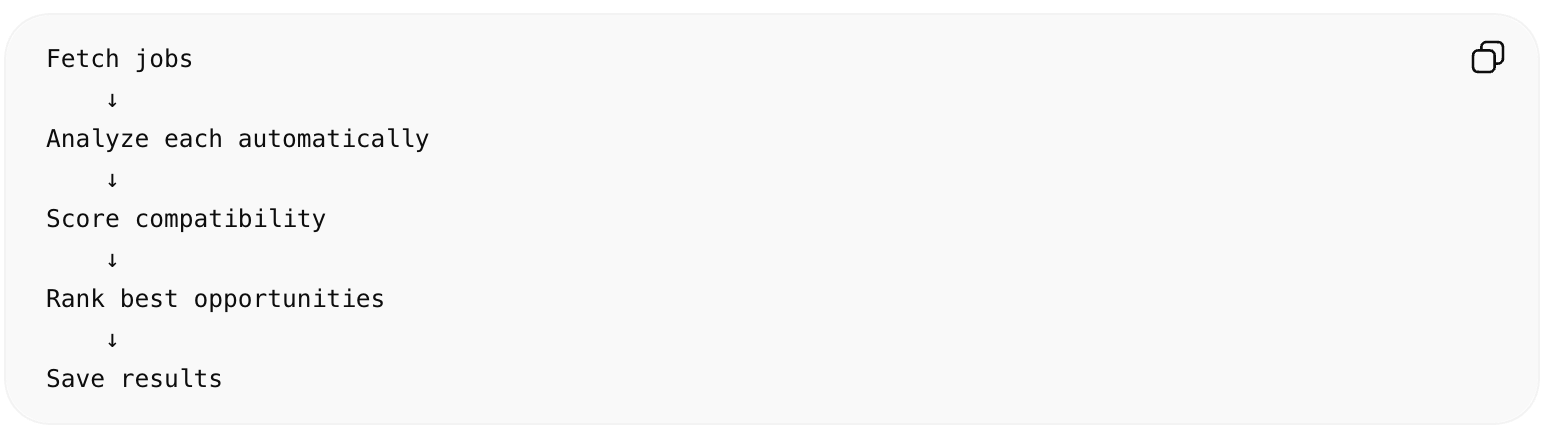


**TODO - Optimise the flow**

Batching

Async Execution

Caching

Retries

Token Tracking

In [37]:
def evaluate_jobs(jobs_df,resume_text,top_n=10):
  results = []
  for _,job in jobs_df.iterrows():
    try:
      analysis = analyze_resume(resume_text,job["description"])
      analysis["title"] = job["title"]
      analysis["company"] = job["company"]
      analysis["location"] = job["location"]
      analysis["url"] = job["url"]
      results.append(analysis)

    except Exception as e :
      print(f"Failed processsing job : {job['title']}")
      print(e)
  results_df = pd.DataFrame(results)
  results_df = results_df.sort_values(by="match_score",ascending=False)
  return results_df.head(top_n)

**Test The Pipeline**


In [ ]:
jobs_df = fetch_remote_jobs(
    query="AI Engineer",
    limit=4
)
print(jobs_df)
results = evaluate_jobs(
    jobs_df=jobs_df,
    resume_text=resume_text,
    top_n=4
)

results.head()

                           title                   company location   url  \
0    AI Senior Engineer - Vision                      Able     None  None   
1  Patient Care Advisor - Remote          Sun River Health     None  None   
2     Director, Growth Marketing                       PDQ     None  None   
3           Software Engineer II  Precision Medicine Group     None  None   

                                         description  
0  <p>Back in 2012, we were a group of engineers ...  
1  <p><a href="https://himalayas.app/companies/su...  
2  <p style="font-family:"><b><strong style="font...  
3  <h3>Position Summary:</h3><p>The candidate wil...  


,match_score,matched_skills,missing_skills,title,company,location,url
0,35,"[Python, machine learning, LangChain]","[Computer Vision, Vision-Language Models (GPT-...",AI Senior Engineer - Vision,Able,None,None
1,20,[],"[Call center experience, Healthcare customer s...",Patient Care Advisor - Remote,Sun River Health,None,None
2,10,"[automation systems, machine learning]","[B2B growth experience, Demand generation, Cus...","Director, Growth Marketing",PDQ,None,None
3,10,"[APIs, automation systems]","[GIT fundamentals, SQL Server, Windows, HTML, ...",Software Engineer II,Precision Medicine Group,None,None


**Multi-Agent Architecture**

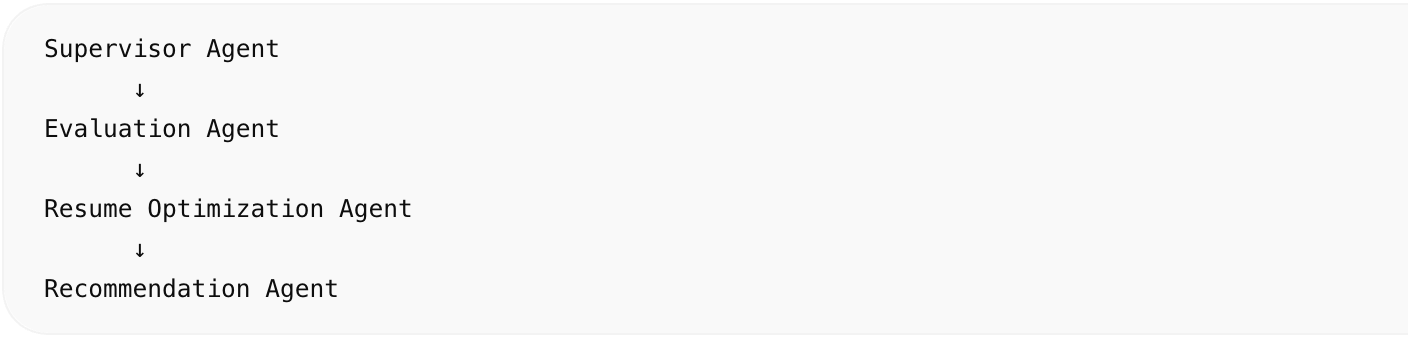

**Evaluation Agent**

In [ ]:
evaluation_prompt = f"""
 You are a senior AI recruiter.

    Evaluate candidate-job compatibility.

    Return only valid JSON.
"""
evaluation_agent = create_agent(evaluation_prompt)


**Resume Optimisation Agent**

In [ ]:
resume_optimisation_promt =f"""
You are an expert resume optimization specialist.

    Improve resumes for ATS systems and recruiter readability.

    Keep information truthful.
    """
resume_optimisation_agent = create_agent(resume_optimisation_promt)



**Recommendation Agent**

In [38]:
def recommend_best_jobs(ranked_jobs_df,top_n):
  jobs_summary = ranked_jobs_df.head(top_n).to_dict(
        orient="records"
    )
  recommendation_prompt = f"""
    Analyze these ranked jobs and recommend
    which opportunities should be prioritized.

    Jobs:
    {jobs_summary}

    Return:
    - best opportunities
    - reasoning
    - strategic advice
    """
  recommendations = create_agent(recommendation_prompt)
  return recommendations


In [ ]:
recommendations = recommend_best_jobs(
    ranked_jobs_df=results,
    top_n=4
)

print(recommendations)

Based on the provided ranked jobs and your skill set, here's a detailed analysis and recommendation:

---

### **Best Opportunities**

1.  **AI Senior Engineer - Vision** (Company: Able) - **Match Score: 35**
2.  **Patient Care Advisor - Remote** (Company: Sun River Health) - **Match Score: 20**

---

### **Reasoning**

1.  **AI Senior Engineer - Vision (Able) - TOP PRIORITY**
    *   **Highest Match Score:** With a score of 35, this is by far the strongest match among the options.
    *   **Strong Foundational Matches:** Your matched skills (`Python`, `machine learning`, `LangChain`) are core to modern AI/ML development. `Python` is the industry standard, `machine learning` is the domain, and `LangChain` demonstrates experience with advanced NLP/LLM frameworks.
    *   **Missing Skills are Specializations:** While the list of missing skills is extensive, many of them (`Computer Vision`, `Vision-Language Models`, `Layout Analysis`, specific libraries like `PyMuPDF`, `Donut`, `Pix2Struc

**Persistent Memory System**

In [39]:
MEMORY_FILE = "applications_memory.csv"
def initialize_memory():
  if not os.path.exists(MEMORY_FILE):
    memory_df = pd.DataFrame(columns=[
        "job_id",
        "title",
        "company",
        "match_score",
        "status"
    ])
    memory_df.to_csv(MEMORY_FILE, index = False)
    print("Memory initialized.")
def load_memory():
    return pd.read_csv(MEMORY_FILE)
def save_application(job):
  memory_df = load_memory()
  new_row = {
      "job_id" : job["url"],
      "title" : job["title"],
      "company": job["company"],
      "match_score": job["match_score"],
      "status": "analyzed"
  }
  memory_df = pd.concat([memory_df,pd.DataFrame([new_row])], ignore_index =True)
  memory_df.to_csv(MEMORY_FILE, index=False)
  print(f"Saved: {job['title']}")

**Testing the memory**

In [ ]:
initialize_memory()
for _, job in results.iterrows():
  save_application(job)

memory_df = load_memory()
memory_df.head()

Saved: AI Senior Engineer - Vision
Saved: Patient Care Advisor - Remote
Saved: Director, Growth Marketing
Saved: Software Engineer II


,job_id,title,company,match_score,status
0,NaN,AI Senior Engineer - Vision,Able,35,analyzed
1,NaN,Patient Care Advisor - Remote,Sun River Health,20,analyzed
2,NaN,"Director, Growth Marketing",PDQ,10,analyzed
3,NaN,Software Engineer II,Precision Medicine Group,10,analyzed
4,NaN,AI Senior Engineer - Vision,Able,35,analyzed


**Workflow State**

In [ ]:
state = {
    "jobs": [],
    "ranked_jobs": [],
    "recommendations": ""
}

workflow_state = {
    "jobs_df": None,
    "ranked_jobs": None,
    "recommendations": None
}

In [35]:
def fetch_jobs(query,limit):
  print("Fetching jobs...")

  jobs_df = fetch_remote_jobs(
        query=query,
        limit=limit
    )

  print(f"Fetched {len(jobs_df)} jobs")

    # Load memory
  memory_df = load_memory()

    # Existing processed jobs
  existing_job_ids = set(
        memory_df["job_id"].tolist()
    )

    # Filter duplicates
  new_jobs_df = jobs_df[
        ~jobs_df["url"].isin(existing_job_ids)
    ]

  print(f"New jobs after filtering: {len(new_jobs_df)}")
  return new_jobs_df

**Test Workflow**

In [40]:
def run_job_workflow(query, resume_text):
  state = {}
  print("Fetching the jobs....")
  jobs_df = fetch_jobs(query=query,limit=4)
  #fetch_remote_jobs(query =query, limit =4)
  state["jobs_df"] = jobs_df

  print("Evaluating jobs.....")
  ranked_jobs = evaluate_jobs(
      jobs_df=jobs_df,
      resume_text=resume_text,
      top_n=4
  )
  state["ranked_jobs"] = ranked_jobs

  print("Generating recommendations...")

  recommendations = recommend_best_jobs(
      ranked_jobs_df=ranked_jobs,
      top_n=4
  )
  state["recommendations"] = recommendations

  return state



In [ ]:
final_state = run_job_workflow(
    query="Data Analyst",
    resume_text=resume_text
)
print(final_state)

Fetching the jobs....
Fetching jobs...
Fetched 4 jobs
New jobs after filtering: 4
Evaluating jobs.....
Generating recommendations...
{'jobs_df':                            title                   company location   url  \
0    AI Senior Engineer - Vision                      Able     None  None   
1  Patient Care Advisor - Remote          Sun River Health     None  None   
2     Director, Growth Marketing                       PDQ     None  None   
3           Software Engineer II  Precision Medicine Group     None  None   

                                         description  
0  <p>Back in 2012, we were a group of engineers ...  
1  <p><a href="https://himalayas.app/companies/su...  
2  <p style="font-family:"><b><strong style="font...  
3  <h3>Position Summary:</h3><p>The candidate wil...  , 'ranked_jobs':    match_score                                     matched_skills  \
0           55  [machine learning, LangChain, APIs, automation...   
2           25                          

**LangGraph**

In [4]:
class JobWorkflowState(TypedDict):
  query: str
  resume_text: str
  jobs_df: object
  ranked_jobs: object
  recommendations: str



**Fetch Jobs Node**

In [46]:
def fetch_jobs_node(state):
  jobs_df = fetch_remote_jobs(query = state["query"], limit=4)
  state["jobs_df"] = jobs_df
  return state

**Evaluate Jobs Node**

In [47]:
def evaluate_jobs_node(state):
  ranked_jobs = evaluate_jobs(jobs_df = state["jobs_df"], resume_text= state["resume_text"], top_n=4)
  state["ranked_jobs"] = ranked_jobs
  return state

**Recommendation Node**

In [53]:
def recommendation_node(state):
  recommendations = recommend_best_jobs(
      ranked_jobs_df =state["ranked_jobs"], top_n=4
  )
  state["recommendations"] = recommendations
  return state

**Build Graph**

In [49]:
workflow = StateGraph(JobWorkflowState)
workflow.add_node(
    "fetch_jobs",
    fetch_jobs_node
)
workflow.add_node(
    "evaluate_jobs",
    evaluate_jobs_node
)
workflow.add_node(
    "recommend_jobs",
    recommendation_node
)

**Connect Nodes**

In [50]:
workflow.set_entry_point("fetch_jobs")
workflow.add_edge( "fetch_jobs", "evaluate_jobs")
workflow.add_edge( "evaluate_jobs", "recommend_jobs")
workflow.add_edge("recommend_jobs", END)


**Compile Workflow**

In [51]:
app = workflow.compile()

**Run Workflow**

In [62]:
final_state = app.invoke(
    {
        "query": "AI Engineer",
        "resume_text": resume_text
    }
)
print(final_state["recommendations"])

Retry attempt 1 failed
429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 40.473281529s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.

TypeError: recommend_best_jobs() missing 1 required positional argument: 'top_n'